# RetinaEdge-DR — Notebook 01 · Quickstart on synthetic data

End-to-end walkthrough of the **training-side contract** on procedural data (no downloads,
runs on a laptop CPU):

1. config + deterministic seeding (`retinaedge.utils`)
2. the shared **ordinal ops** (`retinaedge.models.ordinal_ops`)
3. a procedural synthetic dataset matching the contract's class distribution
4. a DrNet-shaped model (`(B,4)` ordinal + `(B,1)` referable heads, timm backbone)
5. CORAL training loop
6. contract metrics: **QWK**, referable **AUC/sens/spec**, **ECE**

Binding contract: `docs/INTERFACES.md` v1.0 · docs: `docs/TRAINING.md`.

> ⚠️ Research/educational material — **not** a medical device. Synthetic images carry no
> clinical meaning; they only exercise the plumbing.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import timm
import torch
from sklearn.metrics import cohen_kappa_score, confusion_matrix, roc_auc_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
for _p in (REPO, REPO / "src"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import retinaedge
from retinaedge.models.ordinal_ops import (
    expected_grade,
    hard_grade,
    ordinal_probs,
    referable_prob,
)
from retinaedge.utils.config import load_config
from retinaedge.utils.seed import seed_everything

print("retinaedge:", retinaedge.__file__)
print("torch:", torch.__version__, "| timm:", timm.__version__)

/home/z/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


retinaedge: /home/z/my-project/retinaedge-dr/src/retinaedge/__init__.py
torch: 2.14.0+cpu | timm: 1.0.30


## 1 · Config + deterministic seeding

`load_config` reads YAML and applies `dotted.key=value` overrides (JSON-parsed).
We start from `configs/train/smoke.yaml` — the same config `make smoke` uses — and bump the
epoch count a little. Every randomness source goes through `seed_everything(cfg)`, so the
whole notebook is reproducible.

In [2]:
CFG = load_config(REPO / "configs/train/smoke.yaml", overrides=["train.epochs=3"])
seed_everything(CFG["train"]["seed"])

IMG_SIZE = CFG["data"]["img_size"]
N_TRAIN = CFG["data"]["synthetic"]["n_train"]
N_VAL = CFG["data"]["synthetic"]["n_val"]
BATCH = CFG["data"]["batch_size"]
SEED = CFG["train"]["seed"]
# Contract: synthetic class distribution ~ [0.45, 0.20, 0.15, 0.10, 0.10]
CLASS_DIST = np.array([0.45, 0.20, 0.15, 0.10, 0.10])

print(
    f"dataset={CFG['data']['dataset']}  img_size={IMG_SIZE}  batch={BATCH}  "
    f"epochs={CFG['train']['epochs']}  seed={SEED}"
)

dataset=synthetic  img_size=64  batch=16  epochs=3  seed=0


## 2 · Ordinal ops — the heart of the grader

The head emits **K−1 = 4** cumulative logits, one binary task each: `g_k = P(grade > k)`.
Grade probabilities are first differences of the sigmoid CDF estimate
`[1, σ(g0), σ(g1), σ(g2), σ(g3), 0]` (CORAL, Cao/Raschka 2020–21). Because the four binary
heads are not guaranteed monotone during early training, `ordinal_probs` clamps and
re-normalises. **Import these ops — never re-implement them** (contract rule).

Hand-check with monotone logits `g = [2, 1, −1, −2]`, matching
`tests/test_ordinal_ops.py::test_ordinal_probs_matches_hand_computation`:

In [3]:
logits = torch.tensor([[2.0, 1.0, -1.0, -2.0]])
probs = ordinal_probs(logits)

names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
table = {f"{g} {n}": round(float(p), 4) for g, (n, p) in enumerate(zip(names, probs[0]))}
print("grade probs:", table)
print("sum        :", float(probs.sum()))
print("E[Y]       :", float(expected_grade(probs)))
print("argmax     :", int(hard_grade(probs)))
print("P(refer)   :", float(referable_prob(probs)), "  # = P(grade >= 2)")

grade probs: {'0 No DR': 0.1192, '1 Mild': 0.1497, '2 Moderate': 0.4621, '3 Severe': 0.1497, '4 Proliferative DR': 0.1192}
sum        : 1.0
E[Y]       : 1.9999998807907104
argmax     : 2
P(refer)   : 0.7310585975646973   # = P(grade >= 2)


## 3 · Procedural synthetic dataset

Contract: no files on disk, classes drawn from `CLASS_DIST` per split seed
(`default_rng(seed + split_offset)`), and the `__getitem__` contract returns
ImageNet-normalised `float32 CHW` + int grade. Our generator makes crude *fundus-like*
discs where severity correlates with brightness, red-dominance and the number of bright
exudate blobs — enough signal for the ordinal head to learn *something* real.

In [4]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def make_synthetic_split(n: int, seed: int, split_offset: int) -> tuple[np.ndarray, np.ndarray]:
    """Return (images float32 (n,3,H,W) normalised, grades int64 (n,)) per the contract."""
    rng = np.random.default_rng(seed + split_offset)
    y = rng.choice(5, size=n, p=CLASS_DIST)
    size = IMG_SIZE
    yy, xx = np.mgrid[0:size, 0:size]
    cx = cy = (size - 1) / 2
    radius = size * 0.42
    disc = ((xx - cx) ** 2 + (yy - cy) ** 2) <= radius**2
    imgs = np.zeros((n, 3, size, size), dtype=np.float32)
    for i, grade in enumerate(y):
        img = rng.normal(0.22 + 0.05 * grade, 0.02, size=(3, size, size))
        img[:, ~disc] = 0.02  # black surround
        img[0][disc] += 0.10 + 0.03 * grade  # redder fundus
        for _ in range(int(grade)):  # bright exudate blobs
            ang = rng.uniform(0, 2 * np.pi)
            dist = rng.uniform(0, radius * 0.95)
            bx, by = cx + dist * np.cos(ang), cy + dist * np.sin(ang)
            glow = np.exp(-(((xx - bx) ** 2 + (yy - by) ** 2) / (2 * 2.0**2)))
            img += glow[None] * 0.35
        img += rng.normal(0.0, 0.02, size=img.shape)  # sensor noise
        imgs[i] = (img - IMAGENET_MEAN[:, None, None]) / IMAGENET_STD[:, None, None]
    return imgs, y.astype(np.int64)


x_train, y_train = make_synthetic_split(N_TRAIN, SEED, 0)
x_val, y_val = make_synthetic_split(N_VAL, SEED, 1)
print("train:", x_train.shape, "| val:", x_val.shape)
print("train grades:", np.bincount(y_train, minlength=5))
print("val   grades:", np.bincount(y_val, minlength=5))

train: (240, 3, 64, 64) | val: (80, 3, 64, 64)
train grades: [97 48 33 28 34]
val   grades: [29 20 10 13  8]


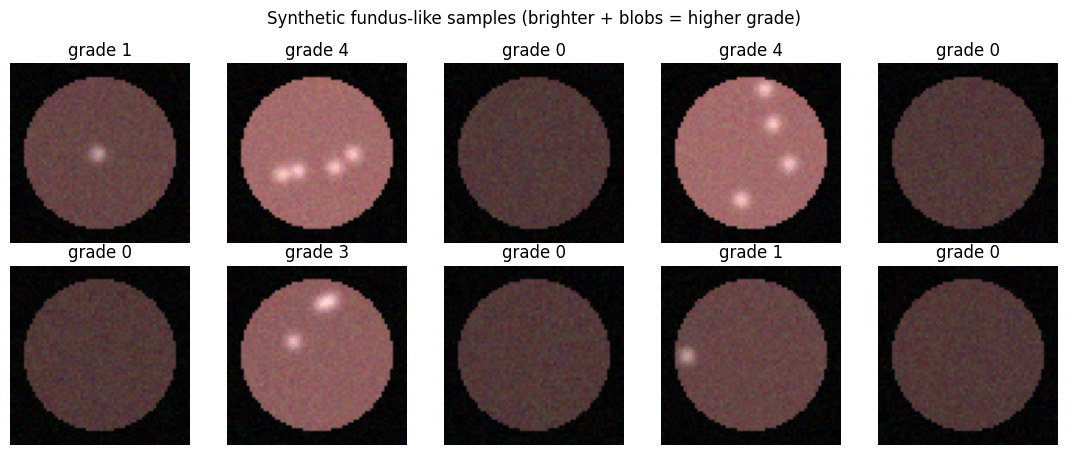

In [5]:
import matplotlib.pyplot as plt

unnorm = x_val[:10] * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for ax, img, g in zip(axes.ravel(), unnorm, y_val[:10]):
    ax.imshow(img.clip(0, 1).transpose(1, 2, 0))
    ax.set_title(f"grade {g}")
    ax.axis("off")
fig.suptitle("Synthetic fundus-like samples (brighter + blobs = higher grade)")
fig.tight_layout()
plt.show()

## 4 · A contract-shaped model

`retinaedge.models.build.build_model` (see `docs/INTERFACES.md`) returns `DrNet` with
`forward(imgs) -> {"ordinal_logits": (B,4), "refer_logits": (B,1)}` on a timm backbone
(`num_classes=0, global_pool="avg"`). We mirror that exactly with a tiny stand-in.

*Timm quirk:* for some families (MobileNetV3) `num_features` ≠ the actual pooled dim, so we
probe with a dummy forward instead of trusting the attribute.

In [6]:
class TinyDrNet(nn.Module):
    """Contract-shaped stand-in for DrNet: ordinal (B,4) + referable (B,1) heads."""

    def __init__(self, backbone: str = "mobilenetv3_small_100", dropout: float = 0.1) -> None:
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=False, num_classes=0, global_pool="avg"
        )
        with torch.no_grad():
            self.embed_dim = int(self.backbone(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)).shape[-1])
        self.drop = nn.Dropout(dropout)
        self.ordinal_head = nn.Linear(self.embed_dim, 4)
        self.refer_head = nn.Linear(self.embed_dim, 1)

    def forward(self, imgs: torch.Tensor) -> dict[str, torch.Tensor]:
        feats = self.drop(self.backbone(imgs))
        return {"ordinal_logits": self.ordinal_head(feats), "refer_logits": self.refer_head(feats)}


seed_everything(SEED)
model = TinyDrNet(dropout=CFG["model"]["dropout"])
n_params = sum(p.numel() for p in model.parameters())
print(f"embed_dim={model.embed_dim}  params={n_params / 1e6:.2f}M")

embed_dim=1024  params=1.52M


## 5 · CORAL training loop

Ordinal part: `BCEWithLogits` on the 4 binarised tasks `y > k`, mean over tasks and batch.
Refer part: `BCEWithLogits` on `y >= 2`. Total =
`ordinal_weight·L_ord + refer_weight·L_ref` with the weights from
`cfg["train"]["loss"]`. The production trainer (`python -m retinaedge.train.trainer`)
wraps the same math with warmup/cosine, EMA, AMP, sampling and early stopping — see
`docs/TRAINING.md`.

In [7]:
def coral_and_refer_loss(outputs: dict, targets: torch.Tensor) -> tuple[torch.Tensor, dict]:
    """Contract loss: cumulative BCE + referable BCE with config weights."""
    levels = (targets[:, None] > torch.arange(4, device=targets.device)[None, :]).float()
    l_ord = nn.functional.binary_cross_entropy_with_logits(outputs["ordinal_logits"], levels)
    l_ref = nn.functional.binary_cross_entropy_with_logits(
        outputs["refer_logits"].squeeze(-1), (targets >= 2).float()
    )
    w = CFG["train"]["loss"]
    total = w["ordinal_weight"] * l_ord + w["refer_weight"] * l_ref
    return total, {"ordinal": float(l_ord), "refer": float(l_ref)}


train_loader = DataLoader(
    TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)),
    batch_size=BATCH,
    shuffle=True,
)
opt = torch.optim.AdamW(
    model.parameters(), lr=CFG["train"]["lr"], weight_decay=CFG["train"]["weight_decay"]
)

for epoch in range(CFG["train"]["epochs"]):
    model.train()
    agg = {"total": 0.0, "ordinal": 0.0, "refer": 0.0}
    for xb, yb in train_loader:
        loss, parts = coral_and_refer_loss(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG["train"]["grad_clip"])
        opt.step()
        agg["total"] += float(loss) * len(xb)
        for k, v in parts.items():
            agg[k] += v * len(xb)
    n = len(train_loader.dataset)
    print(f"epoch {epoch + 1}: " + "  ".join(f"{k}={v / n:.4f}" for k, v in agg.items()))

/tmp/ipykernel_5394/548598034.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  return total, {"ordinal": float(l_ord), "refer": float(l_ref)}


epoch 1: total=0.4870  ordinal=0.3926  refer=0.3145


epoch 2: total=0.4105  ordinal=0.3129  refer=0.3252


epoch 3: total=0.1762  ordinal=0.1351  refer=0.1372


## 6 · Metrics (contract definitions)

| Metric | Definition |
|---|---|
| `qwk` | quadratic-weighted Cohen's κ on argmax grades — **model selection metric** |
| `auc_refer` | ROC-AUC of `P(grade ≥ 2)` |
| `sens`/`spec` | at the Youden-optimal threshold on the accumulated set |
| `ece` | 15-bin expected calibration error on `P(grade ≥ 2)` |

The same numbers come out of `retinaedge.train.metrics.QWKTracker` /
`retinaedge.eval.evaluate` once those modules land.

In [8]:
def ece_binary(conf: np.ndarray, correct: np.ndarray, n_bins: int = 15) -> float:
    """15-bin expected calibration error for a binary confidence score."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    total = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & (conf <= hi) if lo == 0 else (conf > lo) & (conf <= hi)
        if m.any():
            total += float(m.mean()) * abs(float(correct[m].mean()) - float(conf[m].mean()))
    return total


@torch.no_grad()
def evaluate(model: nn.Module, xs: np.ndarray, ys: np.ndarray) -> dict[str, float | np.ndarray]:
    """Contract metrics on one split (QWK, referable AUC/sens/spec, ECE)."""
    model.eval()
    probs = np.concatenate(
        [
            ordinal_probs(model(torch.from_numpy(xs[i : i + 64]))["ordinal_logits"]).numpy()
            for i in range(0, len(xs), 64)
        ]
    )
    pred = probs.argmax(1)
    p_ref = probs[:, 2:].sum(1)
    y_bin = (ys >= 2).astype(int)
    ths = np.unique(p_ref)
    sens = np.array([((p_ref >= t) & (y_bin == 1)).sum() / max(y_bin.sum(), 1) for t in ths])
    spec = np.array([((p_ref < t) & (y_bin == 0)).sum() / max((1 - y_bin).sum(), 1) for t in ths])
    best = int(np.argmax(sens + spec - 1.0))
    return {
        "qwk": cohen_kappa_score(ys, pred, weights="quadratic", labels=range(5)),
        "auc_refer": roc_auc_score(y_bin, p_ref),
        "threshold": float(ths[best]),
        "sens": float(sens[best]),
        "spec": float(spec[best]),
        "ece": ece_binary(p_ref, y_bin.astype(bool)),
        "_pred": pred,
    }


res = evaluate(model, x_val, y_val)
for k, v in res.items():
    if not k.startswith("_"):
        print(f"{k:>10}: {v:.4f}" if isinstance(v, float) else f"{k:>10}: {v}")
cm = confusion_matrix(y_val, res["_pred"], labels=range(5))
import pandas as pd

pd.DataFrame(cm, index=[f"true {i}" for i in range(5)], columns=[f"pred {i}" for i in range(5)])

       qwk: 0.8902
 auc_refer: 1.0000
 threshold: 0.0756
      sens: 1.0000
      spec: 1.0000
       ece: 0.1049


,pred 0,pred 1,pred 2,pred 3,pred 4
true 0,29,0,0,0,0
true 1,14,6,0,0,0
true 2,0,9,1,0,0
true 3,0,0,9,4,0
true 4,0,0,0,1,7


## 7 · Swap in the real modules when they land

This notebook only depends on the *implemented* core (`utils`, `ordinal_ops`). The guarded
imports below pick up the real builder/trainer automatically as soon as those modules are
merged:

In [9]:
try:
    from retinaedge.models.build import build_model

    print("retinaedge.models.build available -> build_model(CFG) can replace TinyDrNet")
except ImportError as exc:
    print(f"retinaedge.models.build not implemented yet ({exc}); TinyDrNet stands in")

try:
    from retinaedge.train.trainer import main as trainer_main

    print("retinaedge.train.trainer available -> use `make train CFG=...` for real runs")
except ImportError as exc:
    print(f"retinaedge.train.trainer not implemented yet ({exc}); loop above stands in")

retinaedge.models.build available -> build_model(CFG) can replace TinyDrNet
retinaedge.train.trainer available -> use `make train CFG=...` for real runs


---

**Next:** `02_calibration_and_export.ipynb` — temperature scaling, ONNX export, runtime
parity, latency and an int8 preview. Docs: `docs/TRAINING.md`, `docs/EXPORT_DEPLOY.md`.

> ⚠️ Research/educational — not a medical device.